In [1]:
# IMPORTACIÓN DE LIBRERÍAS 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
# IMPORTACIÓN DE DATOS

In [4]:
df = pd.read_csv('Housing.csv')

print(f"Dimensiones del dataset: {df.shape}")
df.head(3)

Dimensiones del dataset: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished


In [5]:
# EDA COMPLETO

Estadísticas principales de variables numéricas:


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


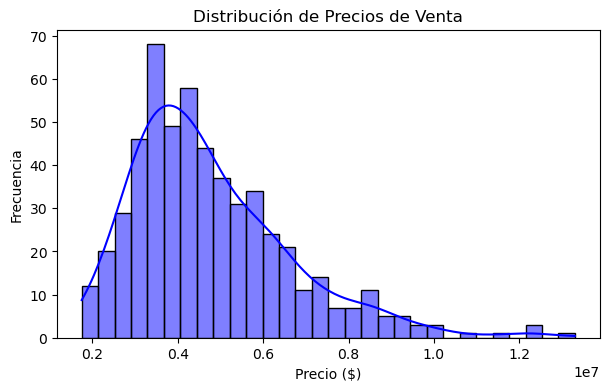

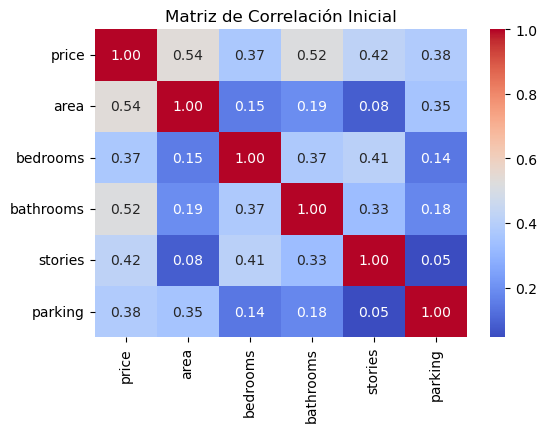

In [6]:
# 1. Estadísticos descriptivos de las variables numéricas
print("Estadísticas principales de variables numéricas:")
display(df.describe())

# 2. Visualización de la distribución de la variable objetivo (Price)
plt.figure(figsize=(7, 4))
sns.histplot(df['price'], kde=True, color='blue', bins=30)
plt.title('Distribución de Precios de Venta')
plt.xlabel('Precio ($)')
plt.ylabel('Frecuencia')
plt.show()

# 3. Matriz de correlación lineal de los atributos numéricos existentes
plt.figure(figsize=(6, 4))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación Inicial')
plt.show()

In [7]:
# FEATURE ENGINEERING

In [8]:
df['area'] = np.log1p(df['area'])
df['bed_bath_ratio'] = df['bedrooms'] / (df['bathrooms'] + 0.1)

In [9]:
# GENERACION DE VARIABLES DUMMY

In [10]:
df_encoded = pd.get_dummies(df, drop_first=True)

print("Estructura final del dataset procesado:")
print(f"Dimensiones: {df_encoded.shape}")
print(f"Variables predictoras: {df_encoded.columns.tolist()}")

Estructura final del dataset procesado:
Dimensiones: (545, 15)
Variables predictoras: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'bed_bath_ratio', 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


In [11]:
# ENTRENAMIENTO / PRUEBA

In [12]:
X = df_encoded.drop(columns=['price'])
y = df_encoded['price']

# 1. División del set de datos en 70% entrenamiento y 30% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# 2. Estandarización (StandardScaler)
columnas_continuas = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'bed_bath_ratio']

scaler = StandardScaler()

# Ajustar y transformar con datos de entrenamiento
X_train[columnas_continuas] = scaler.fit_transform(X_train[columnas_continuas])

# Transformar datos de prueba sin ajustar de nuevo
X_test[columnas_continuas] = scaler.transform(X_test[columnas_continuas])

print(f"Muestras de entrenamiento: {X_train.shape[0]} | Muestras de prueba: {X_test.shape[0]}")

Muestras de entrenamiento: 381 | Muestras de prueba: 164


In [13]:
# REGRESION LINEAL

In [14]:
# 1. Inicializar y entrenar el modelo de Regresión Lineal
modelo_regresion = LinearRegression()
modelo_regresion.fit(X_train, y_train)

# 2. Predecir precios en el conjunto de prueba
y_pred = modelo_regresion.predict(X_test)

# 3. Cálculo de métricas 
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("--- MÉTRICAS DE RENDIMIENTO DEL MODELO ---")
print(f"Coeficiente de Determinación (R²): {r2:.4f}")
print(f"Error Absoluto Medio (MAE): ${mae:,.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): ${rmse:,.2f}")

--- MÉTRICAS DE RENDIMIENTO DEL MODELO ---
Coeficiente de Determinación (R²): 0.6442
Error Absoluto Medio (MAE): $921,198.75
Raíz del Error Cuadrático Medio (RMSE): $1,237,862.50


In [15]:
# ANALISIS DE SENSIBILIDAD E IMPORTANCIA

C:\Users\Marco Antonio Ruiz\AppData\Local\Temp\ipykernel_24556\4109153913.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Variable', data=importancias, palette='viridis')


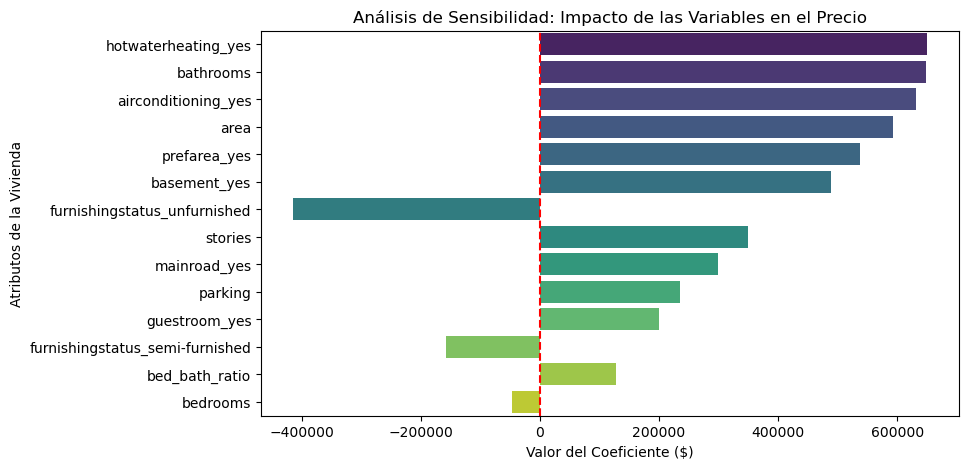


Tabla ordenada de impacto en el precio:
                           Variable    Coeficiente
9               hotwaterheating_yes  650049.081824
2                         bathrooms  648703.052417
10              airconditioning_yes  632375.716850
0                              area  593855.251043
11                     prefarea_yes  537111.633989
8                      basement_yes  488379.418550
13     furnishingstatus_unfurnished -414954.978929
3                           stories  348705.923416
6                      mainroad_yes  298796.331974
4                           parking  236086.882871
7                     guestroom_yes  200754.919097
12  furnishingstatus_semi-furnished -157557.221459
5                    bed_bath_ratio  128272.711707
1                          bedrooms  -46880.658754


In [18]:

# Crear un DataFrame con los coeficientes del modelo
importancias = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo_regresion.coef_
})

# Añadir valor absoluto para ordenar por impacto real sin importar la dirección
importancias['Abs_Coeficiente'] = importancias['Coeficiente'].abs()
importancias = importancias.sort_values(by='Abs_Coeficiente', ascending=False)

# Graficar la importancia de las variables
plt.figure(figsize=(9, 5))
sns.barplot(x='Coeficiente', y='Variable', data=importancias, palette='viridis')
plt.title('Análisis de Sensibilidad: Impacto de las Variables en el Precio')
plt.xlabel('Valor del Coeficiente ($)')
plt.ylabel('Atributos de la Vivienda')
plt.axvline(x=0, color='red', linestyle='--')
plt.show()

print("\nTabla ordenada de impacto en el precio:")
print(importancias[['Variable', 'Coeficiente']])

In [19]:
# VISUALIZACION DE RESULTADOS 

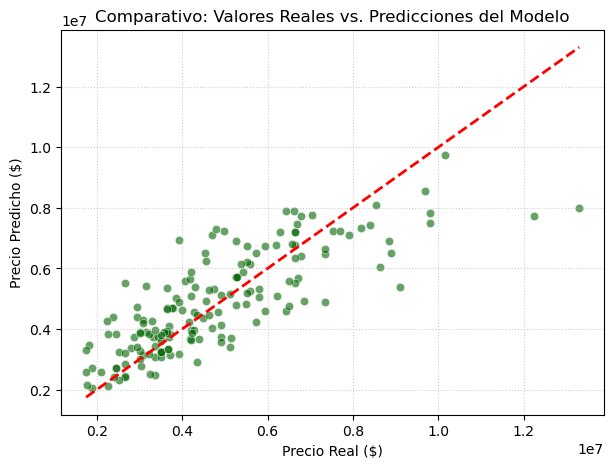

In [20]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='darkgreen')
# Línea de referencia ideal (Predicción Perfecta)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')
plt.title('Comparativo: Valores Reales vs. Predicciones del Modelo')
plt.xlabel('Precio Real ($)')
plt.ylabel('Precio Predicho ($)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

**CONLUSIONES**
-El modelo lineal explica cerca de las dos terceras partes de la variabilidad total en los precios de las casas utilizando las  características proporcionadas.
-La presencia de calefacción por agua caliente y aire acondicionado representan los mayores incrementos directos en el valor    esperado.
-El número de baños y el tamaño del terreno habitable se confirman estadísticamente como los principales motores de plusvalía.
-Nota importante (Las predicciones se desvían en promedio cerca de $921K respecto al valor de mercado real de la vivienda). 